# Structural Surrogate Model (FRAMED dataset)

A small MLP that maps bicycle-frame design parameters (39 inputs) to two structural
performance targets: **Model Mass** and **Sim 1 Dropout Y Disp.**

This is a component model, not the contribution — it will later be loaded frozen as
a differentiable evaluator inside an LLM fine-tuning loop, so the priorities here are:
correctness, a sane baseline to catch bugs, and honest per-target evaluation.

We deliberately predict only 2 of the 10 available performance columns:
- The two safety-factor columns are dropped — the FRAMED authors report these never
  converged under mesh refinement (sharp tube-junction singularities), so they're not
  a reliable regression target.
- Mass is included because it's close to analytic (sum of tube volumes × material
  density) and should be an easy, high-R² sanity check that the pipeline works.
- Dropout Y displacement is included as the "hard" target — it's a real FEA output
  with a heavy-tailed distribution, discussed below.

In [1]:
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("FRAMED Dataset")
ARTIFACT_DIR = Path("checkpoints")
ARTIFACT_DIR.mkdir(exist_ok=True)

print(f"device: {DEVICE}")

device: cuda


## Load data

Drop the index column (`Unnamed: 0`) and the `batch` column (a data-collection
artifact, not a design or performance variable). Keep only the 39 design inputs and
the 2 reduced targets.

In [2]:
df = pd.read_csv(DATA_DIR / "all_structural_data_oh.csv")
df = df.drop(columns=["Unnamed: 0", "batch"])
assert df.isna().sum().sum() == 0, "unexpected missing values"

INPUT_COLS = [
    "Material=Steel", "Material=Aluminum", "Material=Titanium",
    "SSB_Include", "CSB_Include",
    "CS Length", "BB Drop", "Stack", "SS E", "ST Angle", "BB OD", "TT OD",
    "HT OD", "DT OD", "CS OD", "SS OD", "ST OD", "CS F", "HT LX", "ST UX",
    "HT UX", "HT Angle", "HT Length", "ST Length", "BB Length",
    "Dropout Offset", "SSB OD", "CSB OD", "SSB Offset", "CSB Offset", "SS Z",
    "SS Thickness", "CS Thickness", "TT Thickness", "BB Thickness",
    "HT Thickness", "ST Thickness", "DT Thickness", "DT Length",
]
TARGET_COLS = ["Model Mass", "Sim 1 Dropout Y Disp."]
assert len(INPUT_COLS) == 39

X = df[INPUT_COLS].to_numpy(dtype=np.float32)
y = df[TARGET_COLS].to_numpy(dtype=np.float32)
print(f"X: {X.shape}, y: {y.shape}")

X: (4046, 39), y: (4046, 2)


## The heavy tail in `Sim 1 Dropout Y Disp.`

`Model Mass` is well-behaved (roughly symmetric, no extreme values). `Sim 1 Dropout Y
Disp.` is not: most designs sit near -0.03, but there's a real left tail — 10 rows
below -0.3, one of them all the way out at -1.39 (skew ≈ -6.5). These aren't sensor
glitches; they're valid FEA runs of unusually compliant frames, so dropping them would
throw away real physics, not noise.

**Decision: keep every row, and handle the tail in two places instead of one.**

1. **Loss function — Huber, not MSE.** MSE squares the error, so the one row at -1.39
   would dominate the gradient and pull the whole model toward compromising on that
   single point at the expense of the other 4045. Huber loss is linear (not
   quadratic) past a threshold `δ`, so the outlier still contributes signal —the
   model isn't blind to it — but can't dominate training.
2. **Target scaling — `RobustScaler` (median/IQR) instead of `StandardScaler`
   (mean/std) for this target only.** `StandardScaler`'s std is itself computed
   from the same outlier-contaminated data, so it gets inflated (~0.05 here), which
   squashes the *typical* range of values (-0.05 to +0.01) into a tiny sliver of
   normalized space — exactly the range where most of the learning signal lives.
   `RobustScaler` centers/scales on the median and IQR, which are insensitive to the
   single extreme point, so the bulk of the data gets normal-sized gradients.
   `Model Mass` has no such problem, so it keeps a standard `StandardScaler`.

**Tradeoff being made:** the model will still under-fit the exact magnitude of the
-1.39 case — that's the point of Huber, it's a deliberate ceiling on how much any one
point can move the weights. An alternative would be to clip/winsorize the target
(e.g. cap at the 1st/99th percentile) or log-transform it, which would make MSE
training well-behaved too — but clipping silently redefines the prediction target
(the model would never even try to learn "large displacement"), and this dataset's
displacement values include negative and near-zero numbers, so a log transform isn't
directly applicable without a sign-preserving hack. Huber + robust scaling gets most
of the stability benefit without changing what the model is asked to predict.

## Split first, then scale

The 90/10 train/test split happens before any scaling, and scalers are fit on the
training data only — fitting on the full dataset would leak test-set statistics
(mean, std, median, IQR) into the "unseen" evaluation. A further 90/10 split of the
training set carves out a validation slice for early stopping, so the test set stays
untouched until final evaluation.

In [3]:
# 90/10 train/test, then carve a validation slice out of train for early stopping
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.10, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=SEED
)
print(f"train: {X_train.shape[0]}, val: {X_val.shape[0]}, test: {X_test.shape[0]}")

# Inputs: standard scaling, fit on train only
input_scaler = StandardScaler().fit(X_train)
X_train_s = input_scaler.transform(X_train)
X_val_s = input_scaler.transform(X_val)
X_test_s = input_scaler.transform(X_test)

# Targets: independent scalers per column (Mass = standard, Dropout Y = robust — see above)
mass_scaler = StandardScaler().fit(y_train[:, [0]])
disp_scaler = RobustScaler().fit(y_train[:, [1]])

y_train_s = np.hstack([mass_scaler.transform(y_train[:, [0]]), disp_scaler.transform(y_train[:, [1]])])
y_val_s = np.hstack([mass_scaler.transform(y_val[:, [0]]), disp_scaler.transform(y_val[:, [1]])])
y_test_s = np.hstack([mass_scaler.transform(y_test[:, [0]]), disp_scaler.transform(y_test[:, [1]])])

train: 3276, val: 365, test: 405


## Model

`39 → 128 → 128 → 64 → 2`, GELU activations, dropout 0.1 on each hidden layer.
Dataset is small (4046 rows) so this is already generously sized for the problem —
dropout is there mainly to keep the two wide 128-unit layers from memorizing.

In [4]:
class SurrogateMLP(nn.Module):
    def __init__(self, in_dim=39, hidden=(128, 128, 64), out_dim=2, p_drop=0.1):
        super().__init__()
        dims = [in_dim, *hidden]
        layers = []
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(d_in, d_out), nn.GELU(), nn.Dropout(p_drop)]
        layers.append(nn.Linear(dims[-1], out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def to_tensor(arr):
    return torch.as_tensor(arr, dtype=torch.float32)

train_ds = torch.utils.data.TensorDataset(to_tensor(X_train_s), to_tensor(y_train_s))
val_ds = torch.utils.data.TensorDataset(to_tensor(X_val_s), to_tensor(y_val_s))
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=256, shuffle=False)

## Train

AdamW + Huber loss (`delta=1.0`, in normalized target space) computed jointly over
both targets — since both targets are independently scaled to comparable magnitude,
summing their normalized losses doesn't let one target dominate. Early stopping
tracks validation loss and restores the best checkpoint at the end.

In [5]:
model = SurrogateMLP().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.HuberLoss(delta=1.0)

MAX_EPOCHS, PATIENCE = 500, 30
best_val_loss, best_state, patience_ctr = float("inf"), None, 0
history = {"train": [], "val": []}

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += loss_fn(model(xb), yb).item() * xb.size(0)
    val_loss /= len(val_ds)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss, best_state, patience_ctr = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"early stopping at epoch {epoch} (best val loss {best_val_loss:.4f})")
            break

    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}  train {train_loss:.4f}  val {val_loss:.4f}")

model.load_state_dict(best_state)

epoch  20  train 0.0411  val 0.0534


epoch  40  train 0.0305  val 0.0498


epoch  60  train 0.0260  val 0.0419


epoch  80  train 0.0249  val 0.0418


epoch 100  train 0.0227  val 0.0357


epoch 120  train 0.0202  val 0.0357


epoch 140  train 0.0184  val 0.0379
early stopping at epoch 145 (best val loss 0.0339)


<All keys matched successfully>

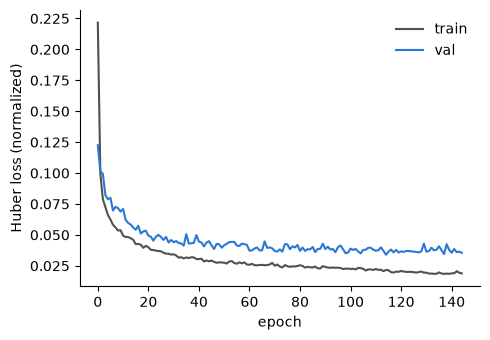

In [6]:
# Quick sanity check: train/val loss should both decrease and roughly track each other
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(history["train"], color="#52514e", label="train")
ax.plot(history["val"], color="#2a78d6", label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("Huber loss (normalized)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## XGBoost baseline

A plain gradient-boosted tree sanity check, trained on the same scaled train split.
XGBoost 2.x+ supports native multi-output regression (`multi_strategy`), so this is
genuinely ~4 lines. Purpose: if XGBoost dramatically outperforms the MLP, that points
to a bug in the network/training loop rather than a fundamental data limit — trees
have no business beating a correctly-trained MLP by a wide margin on tabular data
this size.

In [7]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, tree_method="hist",
                              multi_strategy="multi_output_tree", random_state=SEED)
xgb_model.fit(X_train_s, y_train_s)
y_pred_xgb_s = xgb_model.predict(X_test_s)

## Evaluate

Predictions are inverse-transformed back to physical units (kg, displacement) before
computing R² and RMSE, so the numbers below are directly interpretable — not scaled
residuals.

In [8]:
def inverse_transform_targets(y_scaled):
    mass = mass_scaler.inverse_transform(y_scaled[:, [0]])
    disp = disp_scaler.inverse_transform(y_scaled[:, [1]])
    return np.hstack([mass, disp])

model.eval()
with torch.no_grad():
    y_pred_mlp_s = model(to_tensor(X_test_s).to(DEVICE)).cpu().numpy()

y_true = inverse_transform_targets(y_test_s)          # == y_test, round-trip check
y_pred_mlp = inverse_transform_targets(y_pred_mlp_s)
y_pred_xgb = inverse_transform_targets(y_pred_xgb_s)

rows = []
for i, name in enumerate(TARGET_COLS):
    for label, pred in [("MLP", y_pred_mlp), ("XGBoost", y_pred_xgb)]:
        r2 = r2_score(y_true[:, i], pred[:, i])
        rmse = mean_squared_error(y_true[:, i], pred[:, i]) ** 0.5
        rows.append({"target": name, "model": label, "R2": round(r2, 4), "RMSE": round(rmse, 5)})

results = pd.DataFrame(rows)
results

,target,model,R2,RMSE
0,Model Mass,MLP,0.9676,0.39084
1,Model Mass,XGBoost,0.9052,0.66879
2,Sim 1 Dropout Y Disp.,MLP,0.8449,0.01869
3,Sim 1 Dropout Y Disp.,XGBoost,0.8334,0.01937


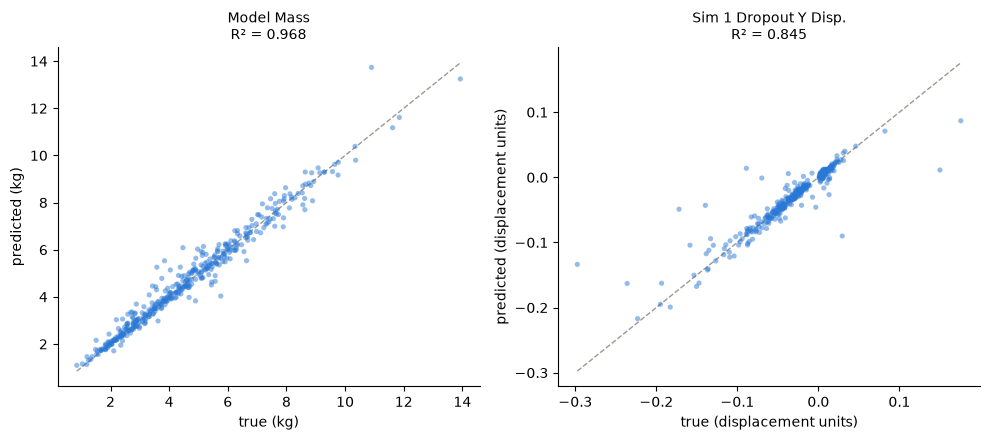

In [9]:
# Predicted-vs-true scatter for the MLP, one panel per target
units = ["kg", "displacement units"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for i, (ax, name, unit) in enumerate(zip(axes, TARGET_COLS, units)):
    t, p = y_true[:, i], y_pred_mlp[:, i]
    lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], color="#9a9890", lw=1, ls="--", zorder=1)  # y = x reference
    ax.scatter(t, p, s=14, color="#2a78d6", alpha=0.5, edgecolors="none", zorder=2)
    r2 = results.query("target == @name and model == 'MLP'")["R2"].item()
    ax.set_title(f"{name}\nR² = {r2:.3f}", fontsize=10)
    ax.set_xlabel(f"true ({unit})"); ax.set_ylabel(f"predicted ({unit})")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## Save

Save the MLP weights (plus architecture config, so it can be reconstructed without
guessing) and all three scalers. Together these are enough to later load the model
frozen and use it as a differentiable evaluator: raw design params → `input_scaler`
→ MLP → inverse-transform with `mass_scaler` / `disp_scaler` → physical-unit
predictions.

In [10]:
torch.save({
    "state_dict": model.state_dict(),
    "config": {"in_dim": 39, "hidden": (128, 128, 64), "out_dim": 2, "p_drop": 0.1},
    "input_cols": INPUT_COLS,
    "target_cols": TARGET_COLS,
}, ARTIFACT_DIR / "surrogate_mlp.pth")

joblib.dump(input_scaler, ARTIFACT_DIR / "input_scaler.joblib")
joblib.dump({"Model Mass": mass_scaler, "Sim 1 Dropout Y Disp.": disp_scaler},
            ARTIFACT_DIR / "target_scalers.joblib")

print(f"saved to {ARTIFACT_DIR.resolve()}")

saved to /home/aipexws2/joshua/LLM_Physics/checkpoints
